In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np 

df = pd.read_csv("09. videojuegos.csv")

df.head()

,Nombre,Plataforma,Anio_Lanzamiento,Genero,Ventas_NA,Ventas_EU,Ventas_JP,Critica_Puntaje
0,Juego_0,Xbox,2011,Aventura,13.516229,8.243746,1.860090,NaN
1,Juego_1,Nintendo,2019,Acción,9.533212,3.665887,3.882065,97.0
2,Juego_2,PC,2021,Aventura,5.151544,1.357899,1.704018,67.0
3,Juego_3,Xbox,2011,Estrategia,5.303223,5.270208,4.653787,75.0
4,Juego_4,Xbox,2019,Estrategia,10.916740,7.722936,4.292064,65.0


# <font color="skyblue">Parte 1: Análisis Visual con Seaborn</font>

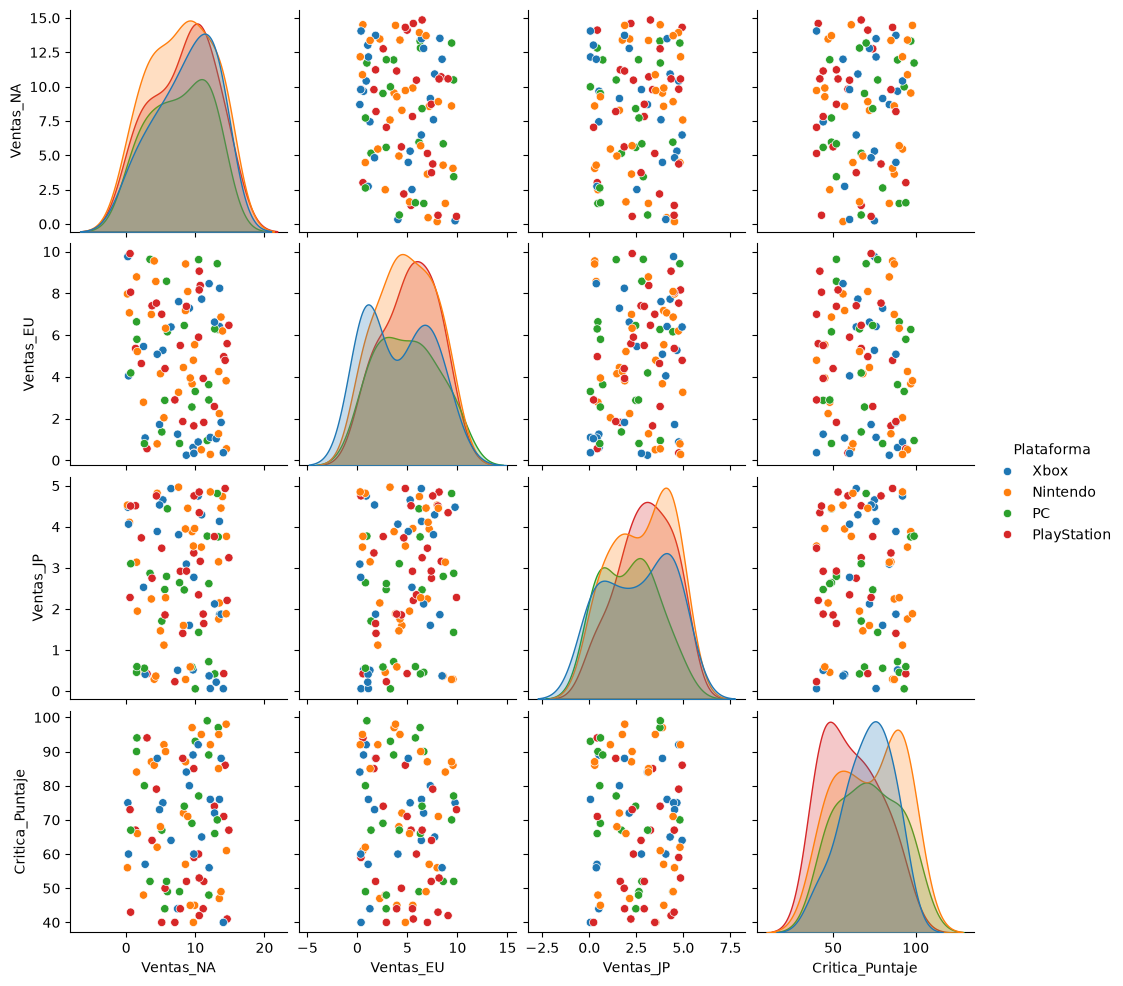

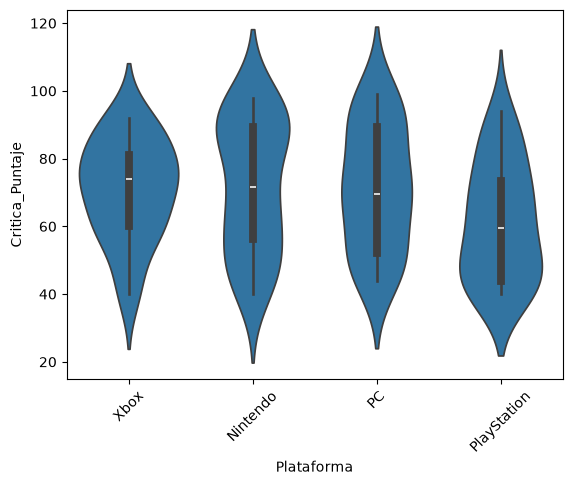

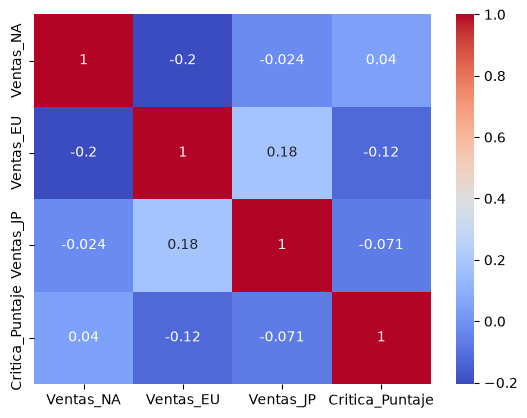

In [2]:
# 1. pairplot
sns.pairplot(df, vars=['Ventas_NA', 'Ventas_EU', 'Ventas_JP', 'Critica_Puntaje'], hue='Plataforma')
plt.show()

# 2. violinplot
sns.violinplot(x='Plataforma', y='Critica_Puntaje', data=df)
plt.xticks(rotation=45) 
plt.show()

# 3. heatmap
matriz_corr = df[['Ventas_NA', 'Ventas_EU', 'Ventas_JP', 'Critica_Puntaje']].corr()
sns.heatmap(matriz_corr, annot=True, cmap="coolwarm")
plt.show()

# <font color="lightgreen">Parte 2: Personalización de Gráficos con Matplotlib</font>

In [3]:
df['Ventas_Globales'] = df['Ventas_NA'] + df['Ventas_EU'] + df['Ventas_JP']

ventas_genero = df.groupby('Genero')['Ventas_Globales'].mean().reset_index()


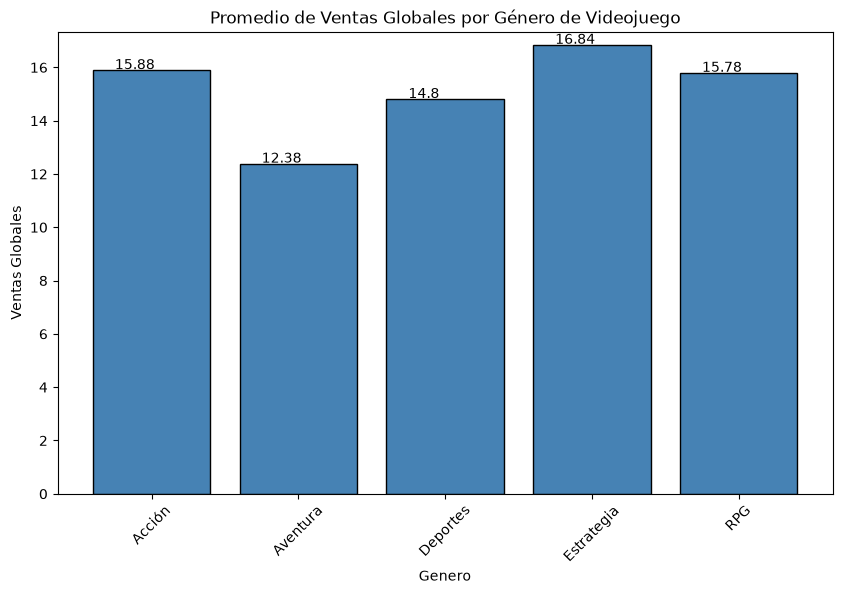

In [4]:
# grafico de barras
plt.figure(figsize=(10,6))
barras = plt.bar(ventas_genero['Genero'], ventas_genero['Ventas_Globales'], color='steelblue', edgecolor='black')

plt.title("Promedio de Ventas Globales por Género de Videojuego")
plt.xlabel("Genero")
plt.ylabel("Ventas Globales")
plt.xticks(rotation=45)

max_venta = ventas_genero['Ventas_Globales'].max()
plt.ylim(0, max_venta + 0.5) 

for barra in barras:
    yval = barra.get_height()
    plt.text(barra.get_x() + 0.15, yval + 0.05, round(yval, 2))

# Guardar 
plt.savefig('ventas_por_genero_personalizado.png', bbox_inches='tight')
plt.show()